In [1]:
pip install numpy pygame


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pygame --no-build-isolation


In [3]:
!pip install --upgrade setuptools wheel


In [4]:

!pip install --upgrade setuptools wheel


!pip install pygame


In [5]:
import pygame
import numpy
import matplotlib

pygame 2.6.1 (SDL 2.28.4, Python 3.10.19)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [6]:
import pygame
import numpy
import matplotlib
print("OK")

OK


Training Finished


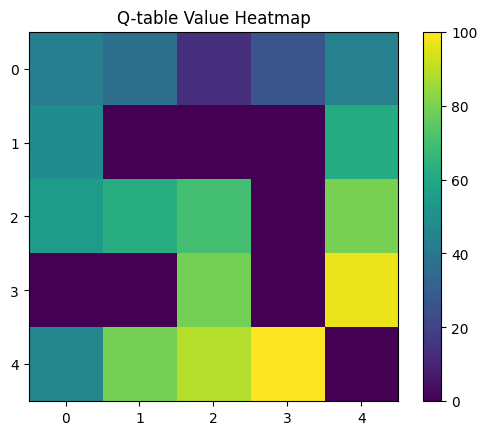

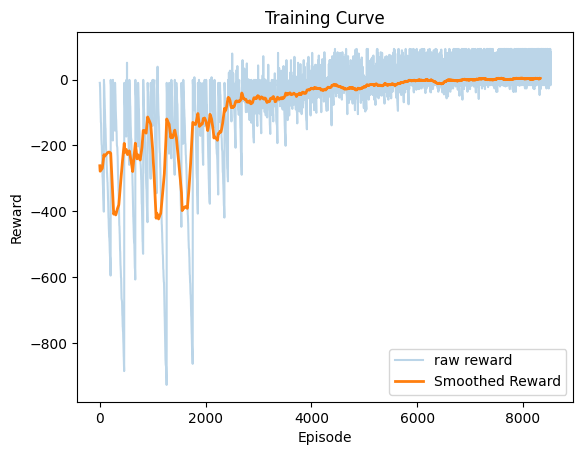

error: display Surface quit

: 

In [ ]:
import numpy as np
import pygame
import random
pygame.quit()      # inorder to prevent notebook crash
pygame.init()
# Maze Settings

MAZE = np.array([
    [0,0,0,0,0],
    [0,1,1,1,0],
    [0,0,0,1,0],
    [1,1,0,1,0],
    [0,0,0,0,0]
])

START = (0,0)
GOAL = (4,4)

ROWS, COLS = MAZE.shape
#action space and reward function
ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT"]
ACTION_MAP = {
    0: (-1, 0),
    1: (1, 0),
    2: (0, -1),
    3: (0, 1)
}
# Q Learning Parameters

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05
episodes = 500

Q = np.zeros((ROWS, COLS, 4))

# Reward Function

def get_reward(state):
    if state == GOAL:
        return 100
    return -1


def valid_state(r, c):
    if r < 0 or r >= ROWS or c < 0 or c >= COLS:
        return False
    if MAZE[r][c] == 1:
        return False
    return True


# Training

episode_rewards = []
for episode in range(episodes):
    total_reward=0

    state = START

    while state != GOAL:

        r, c = state

        # epsilon greedy
        if random.random() < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r, c])

        dr, dc = ACTION_MAP[action]
        nr, nc = r + dr, c + dc

        if not valid_state(nr, nc):
            nr, nc = r, c
            reward = -10
        else:
            reward = get_reward((nr, nc))
        total_reward+=reward
        state = (nr, nc)
        episode_rewards.append(total_reward)

        # Q update
        Q[r, c, action] = Q[r, c, action] + alpha * (
            reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action]
        )

        state = (nr, nc)

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

print("Training Finished")

# Q-table Heatmap


import matplotlib.pyplot as plt

# max Q avalue for each state
value_map = np.max(Q, axis=2)

plt.imshow(value_map)
plt.colorbar()
plt.title("Q-table Value Heatmap")

plt.show()
import matplotlib.pyplot as plt

plt.plot(episode_rewards,alpha=0.3,label="raw reward")
window = 200
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.plot(smoothed, label="Smoothed Reward", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Curve")
plt.legend()
plt.show()



# Pygame Visualization

pygame.init()
font_big = pygame.font.SysFont(None, 48)
font_small = pygame.font.SysFont(None, 28)
font = pygame.font.SysFont(None, 28)

def show_start_screen():
    waiting = True

    while waiting:
        screen.fill((255,255,255))

        title = font_big.render("Maze Q-learning Demo", True, (0,0,0))
        screen.blit(title, (120, 120))

        text1 = font_small.render("Goal: Reach the green cell", True, (0,0,0))
        text2 = font_small.render("Red cells: Obstacles", True, (0,0,0))
        text3 = font_small.render("Agent moves automatically", True, (0,0,0))
        text4 = font_small.render("Press SPACE to start", True, (0,0,0))
        text5 = font_small.render("Press ESC to quit", True, (0,0,0))

        screen.blit(text1, (150, 220))
        screen.blit(text2, (150, 250))
        screen.blit(text3, (150, 280))
        screen.blit(text4, (150, 330))
        screen.blit(text5, (150, 360))

        pygame.display.update()

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                exit()

            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_SPACE:
                    waiting = False
                if event.key == pygame.K_ESCAPE:
                    pygame.quit()
                    exit()

def show_end_screen():
    waiting = True

    while waiting:
        screen.fill((255,255,255))

        title = font_big.render("Goal Reached!", True, (0,150,0))
        screen.blit(title, (180, 200))

        text1 = font_small.render("Press R to restart", True, (0,0,0))
        text2 = font_small.render("Press ESC to quit", True, (0,0,0))

        screen.blit(text1, (200, 260))
        screen.blit(text2, (200, 290))

        pygame.display.update()

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                exit()

            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_r:
                    return True
                if event.key == pygame.K_ESCAPE:
                    pygame.quit()
                    exit()
                    
screen = pygame.display.set_mode((800, 800))
pygame.display.set_caption("Q-learning Maze")

CELL = 80
WIDTH = COLS * CELL+200
HEIGHT = ROWS * CELL+150

screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("Maze Q Learning")

WHITE = (255,255,255)
BLACK = (0,0,0)
GREEN = (0,255,0)
RED = (255,0,0)
BLUE = (0,0,255)

def draw_maze(agent_pos):

    screen.fill(WHITE)

    for r in range(ROWS):
        for c in range(COLS):

            rect = pygame.Rect(c*CELL, r*CELL, CELL, CELL)

            if MAZE[r][c] == 1:
                pygame.draw.rect(screen, BLACK, rect)

            pygame.draw.rect(screen, (200,200,200), rect, 1)

    # goal
    pygame.draw.rect(screen, GREEN,
                     (GOAL[1]*CELL, GOAL[0]*CELL, CELL, CELL))

    # agent
    pygame.draw.rect(screen, RED,
                     (agent_pos[1]*CELL, agent_pos[0]*CELL, CELL, CELL))

    pygame.display.update()



# Run trained agent
show_start_screen()

state = START
clock = pygame.time.Clock()
running = True

while running:

    clock.tick(4)

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    draw_maze(state)

    if state == GOAL:
        restart = show_end_screen()
        if restart:
            state=START
            continue
        else:
            running=False
            continue
    

    r, c = state
    action = np.argmax(Q[r, c])

    dr, dc = ACTION_MAP[action]
    nr, nc = r + dr, c + dc

    if valid_state(nr, nc):
        state = (nr, nc)

pygame.quit()